In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import chess
import chess.svg
import json
import math
import cv2
from pathlib import Path
from IPython.display import display, SVG

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 512
RESULTS_DIR = Path("experiments/results")
MODEL_DIR = Path("models")

In [24]:
# ==========================================
# Configuration
# ==========================================
class Config:
    # 'CNN' / 'MLP' / TRANSFORMER'
    ACTIVE_MODEL = "TRANSFORMER" 
    
    # 'FEN' / 'DATASET'
    TEST_MODE = "FEN" 

    # --- Change if TEST_MODE = "FEN" ---
    FEN_STRING = "2k5/7P/8/8/8/8/8/1K6 w - - 0 1"
    TRUE_LABEL_FOR_FEN = 1 # Manually set the expected class (0-6) for this FEN
    
    # --- Change if TEST_MODE = "DATASET" ---
    ERROR_MAGNITUDE = "6" 
    IDX_IN_LIST = 2 

MODEL_REGISTRY = {
    "CNN": {
        "name": "seresnet_new_v2_16",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "seresnet_new_v2_16_all_indices.json"
    },
    "MLP": {
        "name": "probs_mlp_v4",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "index_file": "run_2026_01_22_probs_mlp_v4_all_indices.json"
    },
    "TRANSFORMER": {
        "name": "transformer_v1",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v1_all_indices.json"
    },
    "CNN_PROBE": {
        "name": "seresnet_new_v2_16_probe",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "seresnet_new_v1_16_probe_failure_indices.json"
    },
    "MLP_PROBE": {
        "name": "probs_mlp_v4_probe",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "index_file": "probs_mlp_v4_probe_failure_indices.json"
    },
    "TRANSFORMER_PROBE": {
        "name": "transformer_v1_probe",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v1_probe_failure_indices.json"
    }
}

ACTIVE_SETUP = MODEL_REGISTRY[Config.ACTIVE_MODEL]

In [25]:
# ==========================================
# Utility Functions
# ==========================================
def sanitize_fen_for_filename(fen: str) -> str:
    return fen.replace("/", "-").replace(" ", "_")

def tensor_to_fen(tensor):
    index_to_piece = {0:'P', 1:'N', 2:'B', 3:'R', 4:'Q', 5:'K', 
                      6:'p', 7:'n', 8:'b', 9:'r', 10:'q', 11:'k'}
    board = chess.Board(None)
    for piece_idx in range(12):
        for row in range(8):
            for col in range(8):
                if tensor[piece_idx, row, col] == 1:
                    board.set_piece_at(chess.square(col, row), chess.Piece.from_symbol(index_to_piece[piece_idx]))

    board.turn = chess.WHITE if tensor[12, 0, 0] == 1 else chess.BLACK
    castling_fen = ""
    if tensor[13, 0, 0] == 1: castling_fen += "K"
    if tensor[14, 0, 0] == 1: castling_fen += "Q"
    if tensor[15, 0, 0] == 1: castling_fen += "k"
    if tensor[16, 0, 0] == 1: castling_fen += "q"
    board.set_castling_fen(castling_fen if castling_fen else "-")

    ep_rows, ep_cols = np.where(tensor[18] == 1)
    if len(ep_rows) > 0:
        board.ep_square = chess.square(ep_cols[0], ep_rows[0])
    return board.fen()

def fen_to_tensor(fen):
    board = chess.Board(fen)
    tensor = np.zeros((19, 8, 8), dtype=np.float32)
    piece_to_channel = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        row, col = divmod(square, 8)
        tensor[piece_to_channel[piece.symbol()], row, col] = 1
    
    if board.turn == chess.WHITE: tensor[12, :, :] = 1
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, :, :] = 1
    if board.has_queenside_castling_rights(chess.WHITE): tensor[14, :, :] = 1
    if board.has_kingside_castling_rights(chess.BLACK): tensor[15, :, :] = 1
    if board.has_queenside_castling_rights(chess.BLACK): tensor[16, :, :] = 1
    if board.is_check(): tensor[17, :, :] = 1
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        tensor[18, row, col] = 1
    return tensor

def vector_to_fen(vector):
    index_to_piece = {0:'P', 1:'N', 2:'B', 3:'R', 4:'Q', 5:'K', 6:'p', 7:'n', 8:'b', 9:'r', 10:'q', 11:'k'}
    board = chess.Board(None) 
    for piece_idx in range(12):
        for square in range(64):
            if vector[piece_idx * 64 + square] == 1:
                board.set_piece_at(square, chess.Piece.from_symbol(index_to_piece[piece_idx]))
                
    board.turn = chess.WHITE if vector[768] == 1 else chess.BLACK
    castling_fen = ""
    if vector[769] == 1: castling_fen += "K"
    if vector[770] == 1: castling_fen += "Q"
    if vector[771] == 1: castling_fen += "k"
    if vector[772] == 1: castling_fen += "q"
    board.set_castling_fen(castling_fen if castling_fen else "-")
    return board.fen()

def fen_to_vector(fen):
    board = chess.Board(fen)
    vector = np.zeros(775, dtype=np.float32)
    piece_to_idx = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        vector[piece_to_idx[piece.symbol()] * 64 + square] = 1
        
    if board.turn == chess.WHITE: vector[768] = 1
    if board.has_kingside_castling_rights(chess.WHITE): vector[769] = 1
    if board.has_queenside_castling_rights(chess.WHITE): vector[770] = 1
    if board.has_kingside_castling_rights(chess.BLACK): vector[771] = 1
    if board.has_queenside_castling_rights(chess.BLACK): vector[772] = 1
    return vector

In [26]:
# ==========================================
# Dataset & Models
# ==========================================
class ChessDataset(Dataset):
    def __init__(self, root_dir: Path, split: str):
        self.X = np.load(root_dir / f"{split}_X.npy", mmap_mode='r')
        self.y = np.load(root_dir / f"{split}_y.npy", mmap_mode='r')

    def __len__(self): return self.X.shape[0]
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_shape=775, output_shape=7):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_shape, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, output_shape)
        )
    def forward(self, x): return self.network(x)

# --- CNN ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.mlp(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x.div(keep_prob) * random_tensor

class ResidualBlock(nn.Module):
    def __init__(self, channels, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1, self.bn2 = nn.BatchNorm2d(channels), nn.BatchNorm2d(channels)
        self.relu, self.se = nn.ReLU(), SEBlock(channels, reduction=8)
        self.drop_path = DropPath(drop_prob) if drop_prob > 0. else nn.Identity()
    def forward(self, x):
        identity = x 
        x = self.se(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))
        return self.relu(self.drop_path(x) + identity)

class SEResNet(nn.Module):
    def __init__(self, in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0):
        super().__init__()
        self.initialconv = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU()
        )
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_blocks)]
        self.res_tower = nn.Sequential(*[ResidualBlock(channels, drop_prob=dpr[i]) for i in range(num_blocks)])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(32, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.bottleneck(self.res_tower(self.initialconv(x))))

# --- TRANSFORMER ---
class Ffn(nn.Module):
    def __init__(self, embed_dim, ffn_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)
        self.activation = nn.ReLU() 
        self.linear2 = nn.Linear(ffn_dim, embed_dim)
    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_blocks):
        super().__init__()
        self.alpha = math.pow(2.0 * num_blocks, -0.25)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(embed_dim), nn.LayerNorm(embed_dim)
        self.ffn = Ffn(embed_dim, ffn_dim)
    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = x + attn_out * self.alpha
        identity = self.ln1(x)
        x = identity + self.ffn(identity) * self.alpha
        return self.ln2(x)

class Transformer(nn.Module):
    def __init__(self, input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7):
        super().__init__()
        self.embedding = nn.Linear(input_channels, embed_dim)
        self.embed_activation = nn.ReLU()
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        nn.init.normal_(self.pos_embedding, mean=0, std=0.02)
        
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ffn_dim, num_blocks) for _ in range(num_blocks)])
        self.classifier_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(), nn.Linear(embed_dim // 2, num_classes)
        )
    def forward(self, x):
        x = x.permute(0, 2, 3, 1).flatten(1, 2)
        x = self.embed_norm(self.embed_activation(self.embedding(x))) + self.pos_embedding
        for block in self.blocks: x = block(x)
        return self.classifier_head(x.mean(dim=1))

In [ ]:
# ==========================================
# Visualization
# ==========================================
def save_chess_board_svg(fen, save_name, size=350):
    """
    Generates an SVG image of a chess board from a FEN string and saves it.
    """
    if not save_name.endswith('.svg'):
        save_name += '.svg'
    board = chess.Board(fen)
    board_svg = chess.svg.board(board, size=size)
    with open(save_name, "w") as f:
        f.write(board_svg)
    print(f"Board successfully saved to {save_name}")

def render_heatmap_svg(saliency_64, fen_str, title):
    """
    Helper function to normalize a 64-element array and draw the chessboard.
    Returns board_svg for easy saving. 
    """
    # Normalize between 0.0 and 1.0
    sal_min, sal_max = np.min(saliency_64), np.max(saliency_64)
    if sal_max > sal_min:
        saliency_norm = (saliency_64 - sal_min) / (sal_max - sal_min)
    else:
        saliency_norm = saliency_64

    cmap = plt.get_cmap("viridis")
    fill_dict = {}
    
    for square_idx in range(64):
        val = saliency_norm[square_idx]
        rgba = cmap(val)
        hex_color = mcolors.to_hex(rgba, keep_alpha=False)
        fill_dict[square_idx] = hex_color

    board_svg = chess.svg.board(
        chess.Board(fen_str),
        fill=fill_dict,
        size=350,
        coordinates=False,
        style=".square { stroke: white; stroke-width: 1.5px; }"
    )
    
    print(title)
    display(SVG(board_svg))

    return board_svg

class SaliencyExtractor:
    def __init__(self, model):
        self.model = model.eval()
        
    def generate_saliency(self, input_tensor, target_class):
        self.model.zero_grad()
        input_tensor.requires_grad = True
        
        preds = self.model(input_tensor)
        score = preds[0, target_class]
        score.backward()
        
        grads = input_tensor.grad.data.cpu().numpy()[0]
        if len(grads.shape) == 3: # Flatten 3D tensors cleanly inside the class
            grads = grads.flatten()
        return grads

def plot_chess_gradients(gradients):
    fig, ax1 = plt.subplots(figsize=(15, 6))
    ax1.plot(gradients, color="b", linewidth=1, label='Gradient Magnitude')
    channels = ['P', 'N', 'B', 'R', 'Q', 'K', 'p', 'n', 'b', 'r', 'q', 'k']
    
    y_min, y_max = np.min(gradients), np.max(gradients)
    y_range = y_max - y_min
    text_y_pos = y_max + (y_range * 0.05) 
    
    for i, channel in enumerate(channels):
        start_idx, end_idx = i * 64, (i + 1) * 64
        if i % 2 == 0:
            ax1.axvspan(start_idx, end_idx, color='gray', alpha=0.1, lw=0)
        ax1.axvline(x=end_idx, color='gray', linestyle=':', alpha=0.5)
        ax1.text(start_idx + 32, text_y_pos, channel, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

    ax1.set_title('Gradient Sensitivity by Feature Index', fontsize=14, pad=25)
    ax1.set_xlim(0, 767)
    ax1.set_ylim(y_min, y_max + (y_range * 0.15))
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_chess_saliency_map(gradients, fen_str, true_label, pred_label, save_name, save_board: bool = False):
    piece_grads = gradients[:768].reshape(12, 64)
    saliency = np.sum(np.abs(piece_grads), axis=0)
    title = f"Saliency Overlay (True: {true_label} | Pred: {pred_label})"
    board_svg = render_heatmap_svg(saliency, fen_str, title)

    if save_board:
        if not save_name.endswith(".svg"): save_name += ".svg"
        with open(save_name, "w") as f: f.write(board_svg)
        print(f"Saved SVG to: {save_name}")

class GradCamVisualizer:
    def __init__(self, model):
        self.model = model.eval()
        self.gradients = None
        self.activations = None
        
        target_layer = self.model.bottleneck[0] # target nn.Conv2d in bottleneck
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_gradcam(self, input_tensor, target_class):
        self.model.zero_grad()
        input_tensor.requires_grad = True
        
        preds = self.model(input_tensor)
        score = preds[0, target_class]
        score.backward() # This triggers the gradient hook
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0] 
        
        for i in range(activations.size(0)):
            activations[i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)  
        
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

def plot_gradcam(visualizer, input_tensor, fen, true_label, pred_label, save_name, save_visuals=False):
    heatmap = visualizer.generate_gradcam(input_tensor, pred_label)
    saliency_flat = heatmap.flatten()
    
    title = f"\n--- Grad-CAM Board (True: {true_label} | Pred: {pred_label}) ---"
    
    # Using your 3-argument helper function
    board_svg = render_heatmap_svg(saliency_flat, fen, title)

    if save_visuals:
        svg_filename = f"{save_name}_gradcam.svg"
        with open(svg_filename, "w") as f:
            f.write(board_svg)
        print(f"Saved Grad-CAM to: {svg_filename}")

# --- SE Weight Visualization ---
class SEExtractor:
    def __init__(self, model):
        self.model = model.eval()
        self.se_weights = {}
        
        for i, block in enumerate(self.model.res_tower): 
            block.se.mlp.register_forward_hook(self.get_se_hook(i)) 

    def get_se_hook(self, block_idx):
        def hook(module, input, output):
            self.se_weights[block_idx] = output.detach().cpu().numpy()[0] # calls .get_se_hook(i) immediately and returns hook function object
        return hook
        
    def extract_weights(self, input_tensor):
        with torch.no_grad():
            self.model(input_tensor) # Triggers the forward hooks
        return self.se_weights

def plot_se_weights(extractor, input_tensor, save_name, save_visuals=False):
    weights = extractor.extract_weights(input_tensor)
    
    fig, ax = plt.subplots(figsize=(3.13, 2.5)) 
    
    first_block_idx = 0
    last_block_idx = len(weights) - 1
    
    se_first = weights[first_block_idx]
    se_last = weights[last_block_idx]
    
    x = np.arange(len(se_first))
    
    ax.bar(x - 0.2, se_first, width=0.4, label=f'Block {first_block_idx}', color='skyblue')
    ax.bar(x + 0.2, se_last, width=0.4, label=f'Block {last_block_idx}', color='coral')
    
    ax.set_xlabel("Channel Index", fontsize=9, x=0.47)
    ax.set_ylabel("Excitation Weight", fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.legend(fontsize=8, frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.show()
    
    if save_visuals:
        pdf_filename = f"{save_name}_se_weights.pdf"
        fig.savefig(pdf_filename, format="pdf", bbox_inches="tight", transparent=True)
        print(f"Saved SE chart to: {pdf_filename}")

# --- Transformer Attention Extraction ---
class TransformerAttentionExtractor:
    def __init__(self, model):
        self.model = model.eval()
        self.attentions = {}
        
        for i, block in enumerate(self.model.blocks):
            block.mha.register_forward_hook(self.get_attn_hook(i))
            
    def get_attn_hook(self, layer_idx):
        def hook(module, input, output):
            attn_weights = output[1] # nn.MultiheadAttention returns (attn_output, attn_output_weights)
            if attn_weights is not None:
                self.attentions[layer_idx] = attn_weights.detach().cpu()
        return hook

    def extract_attention(self, input_tensor):
        self.attentions.clear() # Clear out previous runs
        with torch.no_grad():
            self.model(input_tensor)
        return self.attentions
    
def plot_transformer_attention(extractor, input_tensor, fen, piece_square_index, layer_idx=0, save_name=None, save_visuals=False):
    attentions = extractor.extract_attention(input_tensor)
    
    if layer_idx not in attentions or attentions[layer_idx] is None:
        raise ValueError(f"No attention weights found for Layer {layer_idx}.")

    # (Batch, Num_Heads, Seq_Len_Q, Seq_Len_K)
    # e.g., (1, 4, 64, 64)
    attn_layer = attentions[layer_idx]
    num_heads = attn_layer.shape[1]
    
    piece_name = chess.square_name(piece_square_index)
    print(f"Transformer Attention | Layer {layer_idx} | Square: {piece_name.upper()}")
    
    for i in range(num_heads):
        # Extract the specific head's attention for the query piece
        # This collapses the tensor down to a flat 64-element array mapping to the board
        head_attention_64 = attn_layer[0, i, piece_square_index, :].numpy()
        
        title = f"\n--- Head {i+1} ---"
        
        board_svg = render_heatmap_svg(head_attention_64, fen, title)
        
        if save_visuals and save_name:
            svg_filename = f"{save_name}_attention_L{layer_idx}_H{i+1}_{piece_name}.svg"
            with open(svg_filename, "w") as f:
                f.write(board_svg)
            print(f"Saved Attention Head {i+1} to: {svg_filename}")

In [28]:
# ==========================================
# Dataset Alignment Check
# ==========================================
def check_dataset_alignment():
    CHECK_IDX = 1300
    SPLIT = "test"

    planes_dataset = ChessDataset(root_dir=Path("./dataset_planes_cp_probe/"), split=SPLIT)
    bitmaps_dataset = ChessDataset(root_dir=Path("./dataset_bitmaps_cp_probe/"), split=SPLIT)

    X_plane, y_plane = planes_dataset[CHECK_IDX]
    X_bitmap, y_bitmap = bitmaps_dataset[CHECK_IDX]

    fen_from_plane = tensor_to_fen(X_plane)
    fen_from_bitmap = vector_to_fen(X_bitmap)

    print(f"--- Checking Index {CHECK_IDX} ({SPLIT} split) ---")
    print(f"Planes  Label: {y_plane.item()} | FEN: {fen_from_plane}")
    print(f"Bitmaps Label: {y_bitmap.item()} | FEN: {fen_from_bitmap}")

    if fen_from_plane == fen_from_bitmap and y_plane.item() == y_bitmap.item():
        print("\n✅ Match! Both datasets represent the exact same board and evaluation at this index.")
    else:
        print("\n❌ Mismatch! The datasets do not align. You might need to check your data generation pipeline.")

# check_dataset_alignment()

In [29]:
# ==========================================
# Load Model & Data
# ==========================================
if Config.ACTIVE_MODEL == "CNN":
    model = SEResNet(in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0).to(DEVICE)
elif Config.ACTIVE_MODEL == "MLP":
    model = MLP(775, 7).to(DEVICE)
elif Config.ACTIVE_MODEL == "TRANSFORMER":
    model = Transformer(input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7).to(DEVICE)

model_path = MODEL_DIR / f"{ACTIVE_SETUP['name']}.pth"
try:
    model.load_state_dict(torch.load(model_path))
    print(f"Loaded weights for {Config.ACTIVE_MODEL} from {model_path}")
except FileNotFoundError:
    print(f"Weight file not found at {model_path}.")
model.eval()

# Determine Input Data
if Config.TEST_MODE == "DATASET":
    index_path = RESULTS_DIR / ACTIVE_SETUP['name'] / ACTIVE_SETUP['index_file']
    with open(index_path, "r") as f: index_data = json.load(f)
    dataset_idx = index_data[Config.ERROR_MAGNITUDE][Config.IDX_IN_LIST]
    save_name = f"{ACTIVE_SETUP['name']}_idx_{dataset_idx}"
    
    dataset = ChessDataset(root_dir=ACTIVE_SETUP['dataset_dir'], split="test")
    X_sample, y_sample = dataset[dataset_idx]
    true_label = y_sample.item()
    fen = tensor_to_fen(X_sample) if ACTIVE_SETUP['is_3d'] else vector_to_fen(X_sample)
    print(f"\nMode: DATASET | Analyzing Test Sample Index: {dataset_idx}")

elif Config.TEST_MODE == "FEN":
    fen = Config.FEN_STRING
    save_fen = sanitize_fen_for_filename(Config.FEN_STRING)
    save_name = f"{ACTIVE_SETUP['name']}_idx_{save_fen}"
    true_label = Config.TRUE_LABEL_FOR_FEN
    raw_tensor = fen_to_tensor(fen) if ACTIVE_SETUP['is_3d'] else fen_to_vector(fen)
    X_sample = torch.tensor(raw_tensor, dtype=torch.float32)
    print(f"\nMode: FEN STRING")

# Base Prediction Variables
X_input = X_sample.unsqueeze(0).to(DEVICE)
pred_logits = model(X_input)
pred_label = torch.argmax(pred_logits, dim=1).item()

print(f"FEN: {fen}")
print(f"True Label: {true_label} | Predicted: {pred_label}")
print(f"Error Magnitude: {abs(true_label - pred_label)}")

Loaded weights for TRANSFORMER from models\transformer_v1.pth

Mode: FEN STRING
FEN: 2k5/7P/8/8/8/8/8/1K6 w - - 0 1
True Label: 1 | Predicted: 0
Error Magnitude: 1


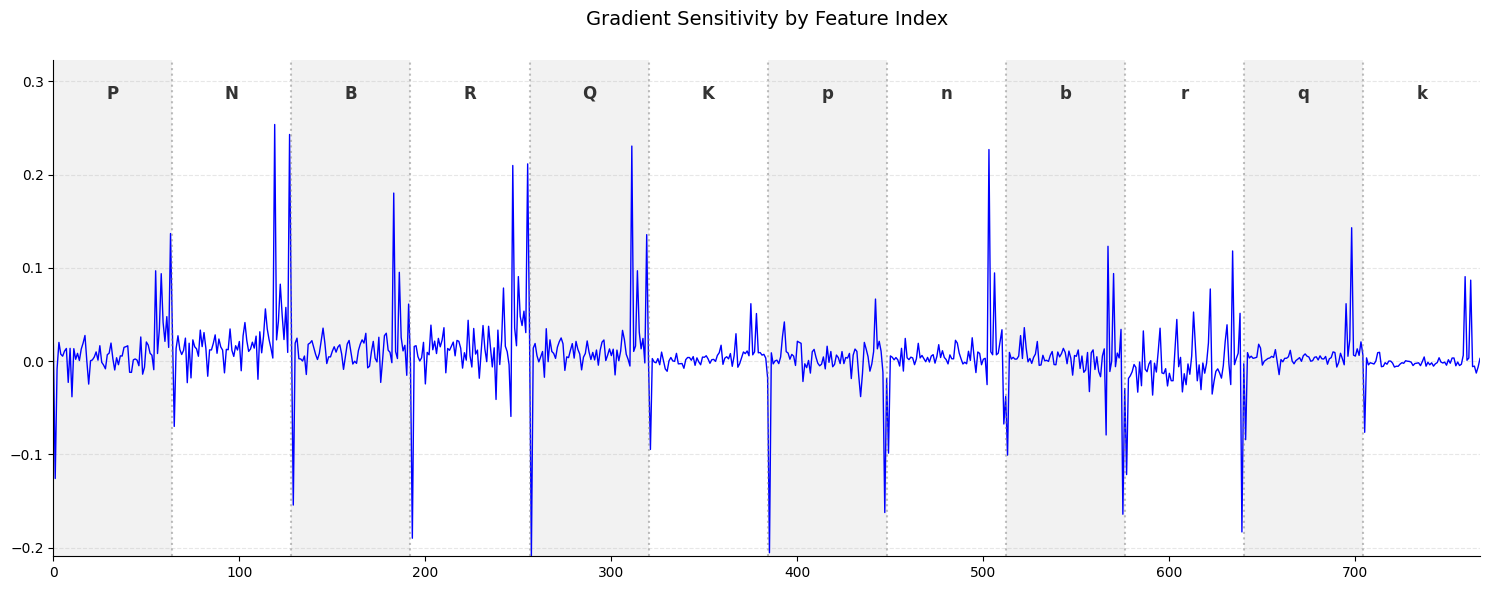

Saliency Overlay (True: 1 | Pred: 0)


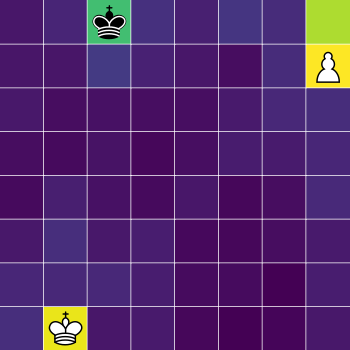

In [30]:
saliency_ext = SaliencyExtractor(model)
grads = saliency_ext.generate_saliency(X_input, pred_label)

plot_chess_gradients(grads)
plot_chess_saliency_map(grads, fen, true_label, pred_label, save_name, save_board=False)

Transformer Attention | Layer 0 | Square: C8

--- Head 1 ---


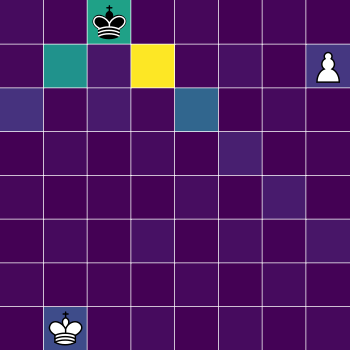

Saved Attention Head 1 to: transformer_v1_idx_2k5-7P-8-8-8-8-8-1K6_w_-_-_0_1_attention_L0_H1_c8.svg

--- Head 2 ---


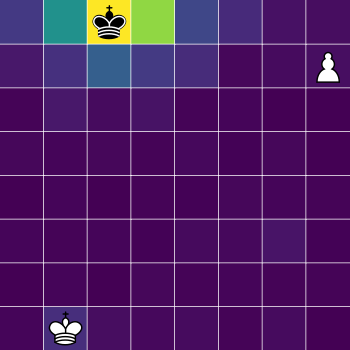

Saved Attention Head 2 to: transformer_v1_idx_2k5-7P-8-8-8-8-8-1K6_w_-_-_0_1_attention_L0_H2_c8.svg

--- Head 3 ---


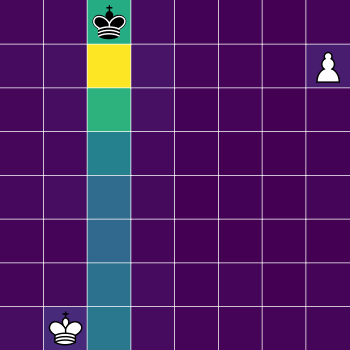

Saved Attention Head 3 to: transformer_v1_idx_2k5-7P-8-8-8-8-8-1K6_w_-_-_0_1_attention_L0_H3_c8.svg

--- Head 4 ---


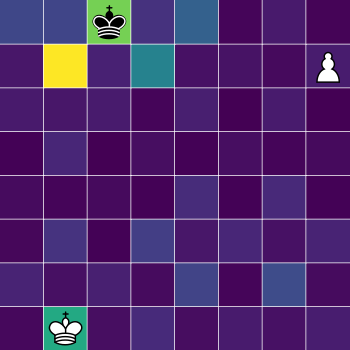

Saved Attention Head 4 to: transformer_v1_idx_2k5-7P-8-8-8-8-8-1K6_w_-_-_0_1_attention_L0_H4_c8.svg


In [36]:
# ==========================================
# Grad-CAM and SE Weights Visualization
# ==========================================
if "CNN" in Config.ACTIVE_MODEL:    
    grad_vis = GradCamVisualizer(model)
    plot_gradcam(grad_vis, X_input, fen, true_label, pred_label, save_name, save_visuals=False)
    
    se_ext = SEExtractor(model)
    plot_se_weights(se_ext, X_input, save_name, save_visuals=False)

elif "TRANSFORMER" in Config.ACTIVE_MODEL:
    target_square_idx = chess.parse_square("c8") 
    
    attn_ext = TransformerAttentionExtractor(model)
    
    plot_transformer_attention(
        extractor=attn_ext, 
        input_tensor=X_input, 
        fen=fen, 
        piece_square_index=target_square_idx, 
        layer_idx=0, # 0-6
        save_name=save_name, 
        save_visuals=True
    )